# Enterprise RAG — Hands-On, Part 8 of 11: The full graph

*Split from `02-hands-on.ipynb` for focused reading — same content, one phase at a time. The
"Setup" cell below re-derives whatever state earlier parts would have produced, so this notebook
runs standalone; you do not need to run the other parts first.*

**Prerequisites:** `OPENAI_API_KEY` in the repo-root `.env`, and `python scripts/ingest.py` already
run (the setup cell below will build the index for you if it is missing).

**Series:** [1. The corpus and its permissions](part01-corpus-and-permissions.ipynb) · [2. The policy engine](part02-policy-engine.ipynb) · [3. Compiling the policy into a database filter](part03-compiling-policy-to-filter.ipynb) · [4. Chunking and ingestion](part04-chunking-and-ingestion.ipynb) · [5. Why hybrid search, demonstrated](part05-hybrid-search.ipynb) · [6. Query transformation](part06-query-transformation.ipynb) · [7. Reranking](part07-reranking.ipynb) · [8. The full graph](part08-full-graph.ipynb) · [9. Attacking it](part09-attacking-it.ipynb) · [10. Evaluation](part10-evaluation.ipynb) · [11. Observability, and what to take away](part11-observability-and-takeaways.ipynb)

---


In [1]:
import sys, json, textwrap
from pathlib import Path

# The package lives in src/ - add it to the path so this notebook runs from anywhere.
ROOT = Path.cwd()
while not (ROOT / "src" / "enterprise_rag").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from enterprise_rag.config import SETTINGS

print("project root :", ROOT)
print("corpus       :", SETTINGS.corpus_dir.relative_to(ROOT))
print("api key      :", "found" if SETTINGS.has_api_key else "MISSING - check .env")
print("embed model  :", SETTINGS.embedding_model)
print("chat model   :", SETTINGS.fast_model)

project root : d:\INTERVIEW PREPARATION\DevRev_Preparation\enterprise_rag_platform
corpus       : data\corpus
api key      : found
embed model  : text-embedding-3-small
chat model   : gpt-4o-mini


### Setup — recap of state from earlier parts


In [2]:
from enterprise_rag.identity import get_principal

TODAY = "2026-08-22"

# Build the index if it is not already there (same check as Part 4).
from enterprise_rag.ingest.store import collection_stats
try:
    stats = collection_stats("meridian")
    assert stats["chunks"] > 0
except Exception:
    from enterprise_rag.ingest.pipeline import ingest
    print("building index...")
    print(ingest().render())

---
# Part 8 - The full graph

Everything above is assembled into a LangGraph state machine:

```
START -> authorize -> plan -> retrieve -> enforce -> grade -+-> generate -> verify -> END
                                                            +-> refuse ------------> END
```

`authorize` runs **first** and `enforce` runs **before the model sees anything**. That ordering is the
security property of the whole system, so it is encoded in the graph's edges rather than left to a
code convention someone can forget.

In [3]:
from enterprise_rag.graph.build import RAGPlatform

platform = RAGPlatform()
# print(platform.graph.get_graph().draw_ascii())

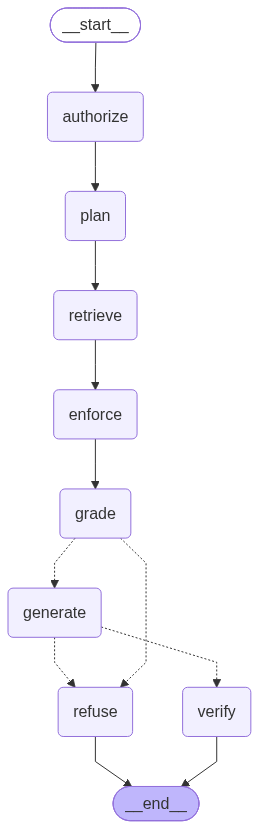

In [4]:
platform.graph

In [5]:
def ask(user_id, question, strategy="enterprise", as_of=TODAY, show=True):
    p = get_principal(user_id)
    res = platform.ask(question, p, strategy=strategy, as_of=as_of, write_trace=False)
    a, t = res["answer"], res["trace"]
    if show:
        print(f"[{p.role}]  strategy={strategy}"
              f"{'  REFUSED' if a.refused else ''}")
        print(textwrap.fill(a.text, 92))
        print(f"\ncited: {[c.doc_id for c in a.citations] or 'none'}")
        if t.denied:
            rules = sorted({d['rule'] for d in t.denied})
            print(f"denied: {sorted({d['doc_id'] for d in t.denied})} by {rules}")
        if t.redacted_count:
            print(f"redacted: {t.redacted_count} chunk(s)")
        print(f"groundedness={t.groundedness}  {t.total_ms:.0f}ms  ${t.cost_usd:.5f}")
    return res

_ = ask("u_marco_t3", "Why should I not scale ingest workers first during a backpressure incident?")

[Tier 3 Escalation Engineer]  strategy=enterprise
You should not scale ingest workers first during a backpressure incident because it
increases the commit rate against an already saturated storage tier, which can worsen the
situation. This mistake has been shown to extend incidents, as evidenced by the 14 March
incident, which was prolonged by approximately 40 minutes due to this action
[RB-101][PM-2026-03-14]. In 90% of historical cases, the bottleneck is the storage-tier
compaction queue, not the ingest workers [RB-101]. Therefore, addressing the compaction
worker pool first is the recommended approach.

cited: ['RB-101', 'PM-2026-03-14']
groundedness=1.0  13491ms  $0.00126


### The headline demo: one question, four roles

This is the cell to run in front of an interviewer.

In [6]:
Q = "What caused the Vertex Financial ingestion problem in March, and are they owed service credits?"

for uid in ["u_lena_t1", "u_marco_t3", "u_sofia_am", "u_tom_contractor", "u_attacker_other_tenant"]:
    print("=" * 96)
    ask(uid, Q, strategy="hybrid")
    print()

[Tier 1 Support Agent]  strategy=hybrid
The Vertex Financial ingestion problem on March 14 was caused by a platform-side compaction
backlog in the EU [TK-4471]. The customer was running agent version 3.1.4, which predates
automatic retry functionality, leading to dropped batches and gaps in their data [TK-4471].
Regarding service credits, the discussion about credits is being handled commercially and
the specific question about SLA credits has been routed to their account manager [TK-4471].

cited: ['TK-4471']
groundedness=1.0  7808ms  $0.00086

[Tier 3 Escalation Engineer]  strategy=hybrid
The ingestion problem for Vertex Financial in March was caused by a platform-side compaction
backlog in the EU [TK-4471]. Vertex Financial is credit-eligible due to breaching their
contractual monthly availability commitment as a result of this incident [PM-2026-03-14].
However, discussions regarding service credits should be handled by their account manager,
not directly with customers [TK-4471].



Four materially different answers from one question, plus one principal who gets nothing:

| Role | What they learn |
|---|---|
| **Tier 1** | Platform-side backlog; credits are an account-manager conversation |
| **Tier 3** | The engineering root cause, and that the account is credit-eligible |
| **Account Manager** | The contractual credit tiers - but *not* the root cause |
| **Contractor** | Nothing; blocked by residency and the external-source rule |
| **Other tenant** | Nothing at all, despite holding every group and top clearance |

Notice the Account Manager gives a **partial** answer rather than refusing. Which half of a question
you can answer depends on your role, so a role-appropriate partial answer is the correct product
behaviour - refusing outright would be over-refusal.

---

**◀ Previous:** [7. Reranking](part07-reranking.ipynb)

**Next ▶:** [9. Attacking it](part09-attacking-it.ipynb)
